### Function Transformation

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [40]:
# import titanic dataset
data = pd.read_csv('../datasets/titanic2.csv',usecols=['Age','Fare','Survived'])

In [41]:
data.head(3)

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875


In [42]:
# Number of null values
data.isnull().sum()

Survived     0
Age         86
Fare         1
dtype: int64

In [5]:
# filling null values
data['Age'].fillna(data['Age'].mean(),inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_3528\2702241186.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(),inplace=True)


In [6]:

data.isnull().sum()

Survived    0
Age         0
Fare        1
dtype: int64

In [7]:
# Filling missing values of fare 
data['Fare'].fillna(data['Fare'].mean(),inplace=True)

C:\Users\dspri\AppData\Local\Temp\ipykernel_3528\2991184580.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Fare'].fillna(data['Fare'].mean(),inplace=True)


In [8]:
data.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [9]:
data.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [10]:
# iloc function is similar as slicing function
x = data.iloc[:,1:3]
y = data.iloc[:,0]

In [11]:
x.head()

,Age,Fare
0,34.5,7.8292
1,47.0,7.0000
2,62.0,9.6875
3,27.0,8.6625
4,22.0,12.2875


In [12]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

In [13]:
### Applying train test split data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [14]:
x_train.shape[0]

292

In [15]:
data.shape[0]

418

In [16]:
y_train.shape[0]

292

In [17]:
x_test.shape[0]

126

###plt.subplot(1, 2, 1)
###           │  │  │
###           │  │  └── Plot number (WHICH one to activate)
###           │  └───── Number of COLUMNS
###           └──────── Number of ROWS

C:\Users\dspri\AppData\Local\Temp\ipykernel_3528\2387690844.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


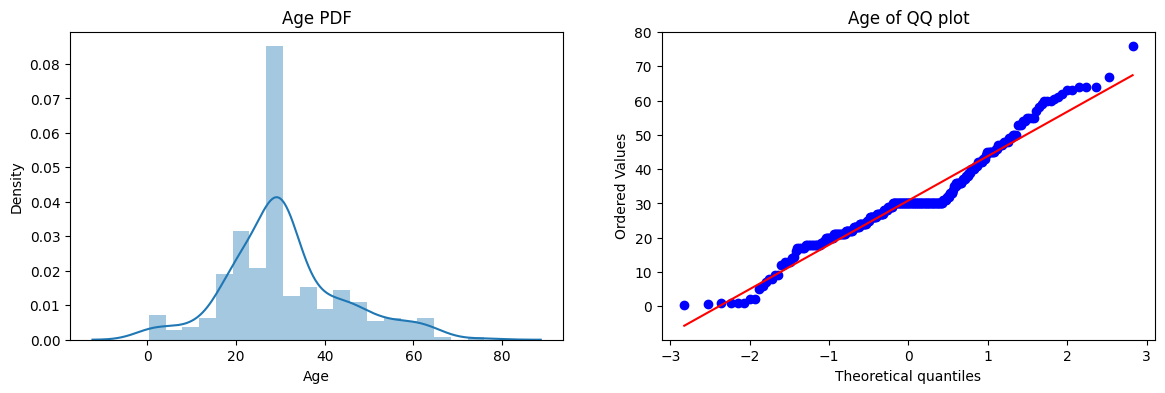

In [18]:
### Checking whether Age feature is following the normal distribution or not
# first figure
plt.figure(figsize=(14,4)) # (width,height)
plt.subplot(1,2,1)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

# second figure
plt.subplot(1,2,2)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age of QQ plot')
plt.show()

C:\Users\dspri\AppData\Local\Temp\ipykernel_3528\3711523607.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


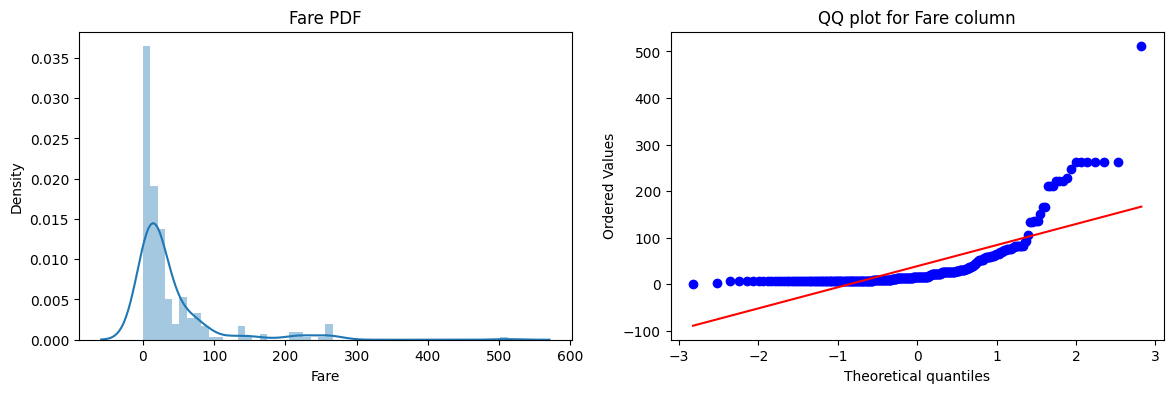

In [19]:
# ckecking whether the fare column is following the normal distribution or not
# figure 1
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')

# figure 2
plt.subplot(1,2,2)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('QQ plot for Fare column')
plt.show()


In [20]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [21]:
# cheing the accuracy score of the data by both LogisticRegression and DecisionTreeClassifier
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred = clf.predict(x_test)
y_pred1 = clf2.predict(x_test)

# printing the accuracy score by both the model
print("The accoracy score by LR is : ",accuracy_score(y_test,y_pred))
print("The accuracy score b the DTC model is : ",accuracy_score(y_test,y_pred1))

The accoracy score by LR is :  0.6746031746031746
The accuracy score b the DTC model is :  0.6111111111111112


### Apply log transformer


In [22]:
# First apply the log transformer then calculate the accuracy score from both the model

In [23]:
x_train.head()

,Age,Fare
118,36.00000,75.2417
271,30.27259,7.7500
114,63.00000,221.7792
311,22.00000,7.2250
131,53.00000,28.5000


In [24]:
y_train.head()

118    0
271    0
114    1
311    0
131    0
Name: Survived, dtype: int64

In [25]:
# creating log transformer object
trf = FunctionTransformer(func=np.log1p) # ip means log base 10

In [26]:
# applyinng transformer over train and test data
x_train_transform = trf.fit_transform(x_train)
x_test_transform = trf.fit_transform(x_test)

In [27]:
x_train_transform

,Age,Fare
118,3.610918,4.333909
271,3.442742,2.169054
114,4.158883,5.406181
311,3.135494,2.107178
131,3.988984,3.384390
...,...,...
71,3.091042,2.185579
106,3.091042,2.177113
270,3.850148,4.333909
348,3.218876,2.674149


In [28]:
# creating object for the Logistictic regression and DecisionTree
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [29]:
# Provide the data to the model so that it can evaluate the parameter
clf.fit(x_train_transform,y_train)
clf2.fit(x_train_transform,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [30]:
# making the prediction from both models
y_pred = clf.predict(x_test_transform)
y_pred2 = clf2.predict(x_test_transform)

In [31]:
# Calculating the accuracy score from both model after applying the log transformer
print('The accuracy score by the Logistic Regression is  : ',accuracy_score(y_pred,y_test))
print('The accuracy score by the decision tree model is  : ',accuracy_score(y_pred2,y_test))
# Note -> By applying the lg transformer the accuracy score of Logistic regression is increases but the accuracy score of the 
# deciosntree is decreases

The accuracy score by the Logistic Regression is  :  0.6904761904761905
The accuracy score by the decision tree model is  :  0.626984126984127


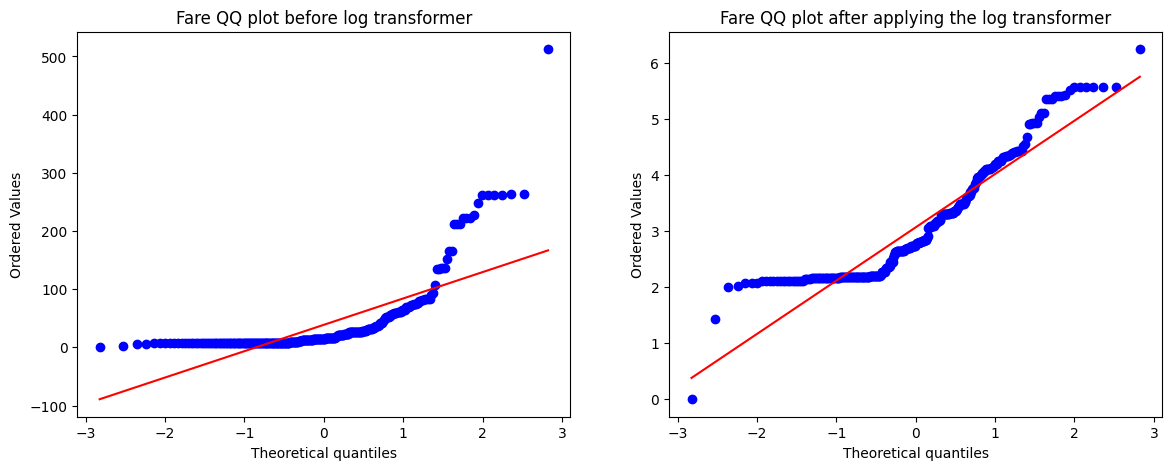

In [32]:
# QQ plot for fare column before and after applying the log transformer
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot before log transformer')

# second figure
plt.subplot(1,2,2)
stats.probplot(x_train_transform['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot after applying the log transformer')

plt.show()

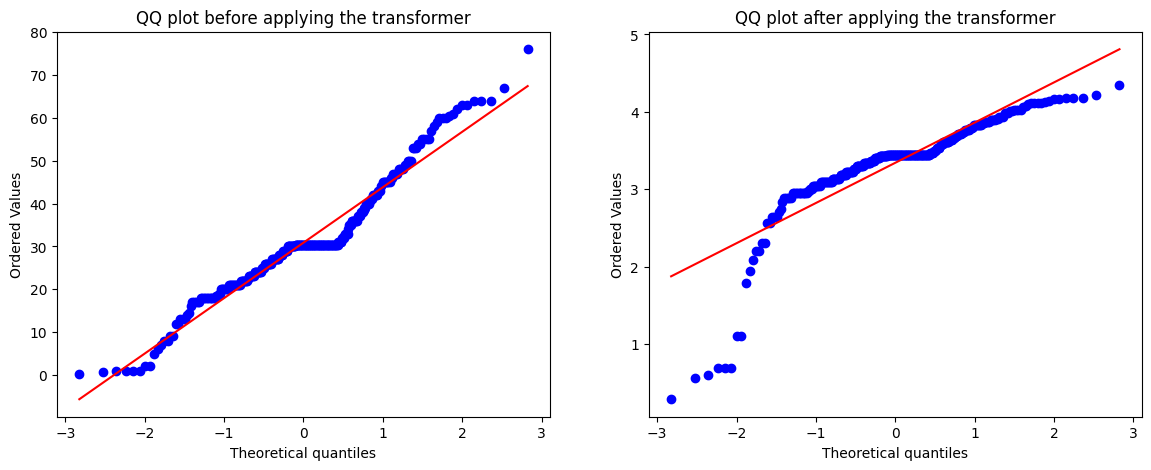

In [33]:
# Drawing the QQ plot for age column
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('QQ plot before applying the transformer')

# second plot
plt.subplot(1,2,2)
stats.probplot(x_train_transform['Age'],dist='norm',plot=plt)
plt.title('QQ plot after applying the transformer')
plt.show()

You can see from the above graph that is applying log transformer is not good for age feature